In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nGrover = 100
nShot = 100
alpha = 0.05

In [3]:
def plotCIWidth(ps, nGrover, nShot, alpha):
    ciWidths = []
    for p in ps:
        theta = np.arcsin(np.sqrt(p))
        kRound = 2 * nGrover + 1
        prob1 = np.sin(kRound * theta) ** 2
        rRound = int(kRound * theta / (0.5 * np.pi))

        p1Width = np.sqrt(0.5 / nShot * np.log(2 / alpha))
        p1Max = min(prob1 + p1Width, 1)
        p1Min = max(prob1 - p1Width, 0)

        if rRound % 2 == 0:
            gammaMin = np.arcsin(np.sqrt(p1Min))
            gammaMax = np.arcsin(np.sqrt(p1Max))
        else:
            gammaMin = 0.5 * np.pi - np.arcsin(np.sqrt(p1Max))
            gammaMax = 0.5 * np.pi - np.arcsin(np.sqrt(p1Min))

        theta_u = (rRound * 0.5 * np.pi + gammaMax) / kRound
        theta_l = (rRound * 0.5 * np.pi + gammaMin) / kRound

        ampSq_u = np.sin(theta_u) ** 2
        ampSq_l = np.sin(theta_l) ** 2
        ampSqWidth = max(ampSq_u - p, p - ampSq_l)

        ciWidths.append(ampSqWidth)

    ax = plt.gca()
    plt.plot(ps, ciWidths)
    plt.show()

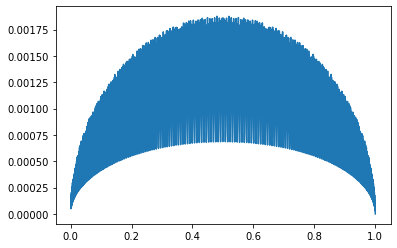

In [4]:
ps = np.linspace(0.001, 1, num=10000)
plotCIWidth(ps, nGrover, nShot, alpha)

0.24999999999999994
0.25679816828709445


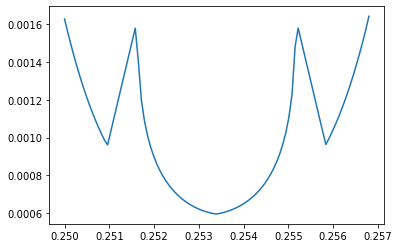

In [5]:
pTrue = 0.2505
thetaTrue = np.arcsin(np.sqrt(pTrue))
r = int((2 * nGrover + 1) * thetaTrue / (0.5 * np.pi))
pl = np.sin((0.5 * np.pi * r) / (2 * nGrover + 1)) ** 2
pu = np.sin((0.5 * np.pi * (r + 1)) / (2 * nGrover + 1)) ** 2
print(pl)
print(pu)

ps = np.linspace(pl, pu, num=100)
plotCIWidth(ps, nGrover, nShot, alpha)

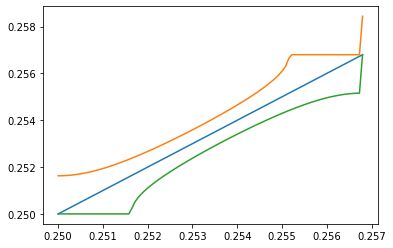

In [6]:
pus = []
pls = []

for p in ps:
    theta = np.arcsin(np.sqrt(p))
    kRound = 2 * nGrover + 1
    prob1 = np.sin(kRound * theta) ** 2
    rRound = int(kRound * theta / (0.5 * np.pi))

    p1Width = np.sqrt(0.5 / nShot * np.log(2 / alpha))
    p1Max = min(prob1 + p1Width, 1)
    p1Min = max(prob1 - p1Width, 0)

    if rRound % 2 == 0:
        gammaMin = np.arcsin(np.sqrt(p1Min))
        gammaMax = np.arcsin(np.sqrt(p1Max))
    else:
        gammaMin = 0.5 * np.pi - np.arcsin(np.sqrt(p1Max))
        gammaMax = 0.5 * np.pi - np.arcsin(np.sqrt(p1Min))

    theta_u = (rRound * 0.5 * np.pi + gammaMax) / kRound
    theta_l = (rRound * 0.5 * np.pi + gammaMin) / kRound

    ampSq_u = np.sin(theta_u) ** 2
    ampSq_l = np.sin(theta_l) ** 2
    ampSqWidth = max(ampSq_u - p, p - ampSq_l)
    pus.append(ampSq_u)
    pls.append(ampSq_l)

ax = plt.gca()
plt.plot(ps, ps)
plt.plot(ps, pus)
plt.plot(ps, pls)
plt.show()

pTrueからestimated pが上振れした方が信頼区間幅は小さい　→　終了しやすい　→　上方バイアス

0.24741334951274946
0.25520006401747375


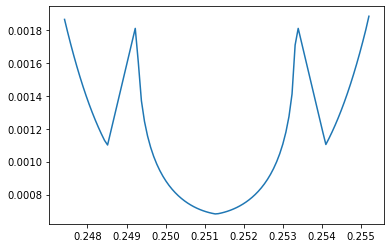

In [7]:
pTrue = 0.2505
nGrover = 87
thetaTrue = np.arcsin(np.sqrt(pTrue))
r = int((2 * nGrover + 1) * thetaTrue / (0.5 * np.pi))
pl = np.sin((0.5 * np.pi * r) / (2 * nGrover + 1)) ** 2
pu = np.sin((0.5 * np.pi * (r + 1)) / (2 * nGrover + 1)) ** 2
print(pl)
print(pu)

ps = np.linspace(pl, pu, num=100)
plotCIWidth(ps, nGrover, nShot, alpha)

In [9]:
np.sin((2 * nGrover + 1) * thetaTrue) ** 2

0.34196064047685215